In [1]:
# Phase 9 – Stage I SRL | Cell 1: Setup + Load Phase 8

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pickle
import gymnasium as gym
from gymnasium import spaces

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase9"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
OUT_MODEL = OUT_DIR / "models"
OUT_LOG  = OUT_DIR / "logs"
for d in [OUT_DATA, OUT_TAB, OUT_FIG, OUT_MODEL, OUT_LOG]:
    d.mkdir(parents=True, exist_ok=True)

P8 = PROJECT / "outputs" / "phase8" / "data"

print("=" * 60)
print("Phase 9 – Stage I Structural Reinforcement | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")

base_features = np.load(P8 / "base_features.npy")
emb_tgn = np.load(P8 / "emb_TGN.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

with open(P8 / "phase8_env_payload.pkl", "rb") as f:
    payload = pickle.load(f)

print(f"base_features : {base_features.shape}")
print(f"emb_TGN       : {emb_tgn.shape}")
print(f"sr_vector     : {sr_vector.shape}")
print(f"nodes         : {len(nodes)}")
print(f"levels        : {payload['levels']}")
print(f"actions       : {payload['action_names']}")
print(f"main embedding: {payload['main_embedding']}")

print("\nCell 1 completed successfully.")

Phase 9 – Stage I Structural Reinforcement | Cell 1
Timestamp : 2026-09-28 09:05:47
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase9
base_features : (378, 16)
emb_TGN       : (378, 32)
sr_vector     : (378,)
nodes         : 18
levels        : ['normal', 'moderate', 'strict']
actions       : ['tax', 'subsidy', 'investment', 'credit']
main embedding: TGN

Cell 1 completed successfully.


In [2]:
# Phase 9 – Cell 2: Save Phase-8 env as module + import

from pathlib import Path
import textwrap
import numpy as np
import pandas as pd

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
ENV_PATH = P8 / "economics_env.py"

print("=" * 60)
print("Phase 9 – Cell 2: Persist & import Phase-8 environment")
print("=" * 60)

env_source = textwrap.dedent('''
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class EconomicsNetworkEnv(gym.Env):
    """Phase-8 economics RL environment (3 levels)."""
    metadata = {"render_modes": []}
    LEVEL_CFG = {
        "normal":   {"obs_noise": 0.01, "action_scale": 0.05, "sr_weight": 1.0, "stability_weight": 0.3, "cost_weight": 0.05, "shock_prob": 0.05, "shock_scale": 0.02, "max_steps": 40},
        "moderate": {"obs_noise": 0.03, "action_scale": 0.04, "sr_weight": 1.2, "stability_weight": 0.5, "cost_weight": 0.10, "shock_prob": 0.10, "shock_scale": 0.04, "max_steps": 40},
        "strict":   {"obs_noise": 0.06, "action_scale": 0.03, "sr_weight": 1.5, "stability_weight": 0.8, "cost_weight": 0.20, "shock_prob": 0.15, "shock_scale": 0.07, "max_steps": 40},
    }

    def __init__(self, base_features, embeddings, sr_vector, panel_index, nodes,
                 level="normal", reward_scale=1.0, seed=None):
        super().__init__()
        assert level in self.LEVEL_CFG
        self.cfg = self.LEVEL_CFG[level]
        self.level = level
        self.reward_scale = reward_scale
        self.base_features = base_features.astype(np.float32)
        self.embeddings = embeddings.astype(np.float32)
        self.sr_vector = sr_vector.astype(np.float32)
        self.panel_index = panel_index.reset_index(drop=True)
        self.nodes = list(nodes)
        self.feat_dim = base_features.shape[1]
        self.emb_dim = embeddings.shape[1]
        self.max_steps = self.cfg["max_steps"]
        obs_dim = (self.feat_dim * 2) + self.emb_dim + 5
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(4,), dtype=np.float32)
        self.rng = np.random.default_rng(seed)
        self.current_features = None
        self.current_sr = None
        self.initial_sr = None
        self.step_count = 0
        self._year_indices = None

    def _sample_year_block(self):
        years = self.panel_index["year"].unique()
        y = int(self.rng.choice(years))
        idx = self.panel_index.index[self.panel_index["year"] == y].to_numpy()
        sub = self.panel_index.loc[idx].copy()
        sub["_ord"] = sub["iso2"].map({n: i for i, n in enumerate(self.nodes)})
        return sub.sort_values("_ord").index.to_numpy()

    def _get_obs(self):
        feat = self.current_features
        obs = np.concatenate([
            feat.mean(0), feat.std(0) + 1e-6,
            self.embeddings[self._year_indices].mean(0),
            np.array([
                float(np.mean(self.current_sr)),
                float(np.std(self.current_sr) + 1e-6),
                float(np.min(self.current_sr)),
                float(np.max(self.current_sr)),
            ], dtype=np.float32),
            np.array([self.step_count / max(self.max_steps, 1)], dtype=np.float32),
        ]).astype(np.float32)
        return obs + self.rng.normal(0.0, self.cfg["obs_noise"], size=obs.shape).astype(np.float32)

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self._year_indices = self._sample_year_block()
        self.current_features = self.base_features[self._year_indices].copy()
        self.current_sr = self.sr_vector[self._year_indices].copy()
        self.initial_sr = self.current_sr.copy()
        self.step_count = 0
        return self._get_obs(), {}

    def step(self, action):
        action = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)
        s = self.cfg["action_scale"]
        tax, subsidy, invest, credit = action * s
        self.current_features = self.current_features + ((subsidy + invest + credit) - 0.5 * tax) * 0.1
        self.current_sr = np.clip(
            self.current_sr + (0.4 * invest + 0.3 * credit + 0.2 * subsidy - 0.3 * tax),
            0.0, 1.5,
        )
        if self.rng.random() < self.cfg["shock_prob"]:
            shock = self.rng.normal(0.0, self.cfg["shock_scale"], size=self.current_sr.shape)
            self.current_sr = np.clip(self.current_sr + shock, 0.0, 1.5)
            self.current_features = self.current_features + float(shock.mean()) * 0.05
        self.step_count += 1
        sr_now = float(np.mean(self.current_sr))
        sr_imp = sr_now - float(np.mean(self.initial_sr))
        reward = self.reward_scale * (
            self.cfg["sr_weight"] * sr_imp
            + self.cfg["stability_weight"] * (-float(np.std(self.current_sr)))
            + self.cfg["cost_weight"] * (-float(np.mean(np.abs(action))))
        )
        trunc = self.step_count >= self.max_steps
        info = {"sr_mean": sr_now, "sr_improve": sr_imp, "level": self.level, "step": self.step_count}
        return self._get_obs(), float(reward), False, trunc, info
''')

ENV_PATH.write_text(env_source, encoding="utf-8")
print(f"Saved env module → {ENV_PATH}")

# Import from phase8 path
import sys
if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

# Load data
base_features = np.load(P8 / "base_features.npy")
emb_tgn = np.load(P8 / "emb_TGN.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

# SB3 check
try:
    import stable_baselines3 as sb3
    from stable_baselines3 import SAC, PPO, TD3, DDPG
    print(f"stable_baselines3: {sb3.__version__}")
except ImportError:
    raise ImportError("Install with: pip install stable-baselines3")

# Smoke test
env = EconomicsNetworkEnv(base_features, emb_tgn, sr_vector, panel, nodes, level="normal", seed=0)
obs, _ = env.reset(seed=0)
print(f"Imported EconomicsNetworkEnv OK | obs={obs.shape} | action={env.action_space.shape}")
print("Levels:", list(EconomicsNetworkEnv.LEVEL_CFG.keys()))
print("\nCell 2 completed successfully.")

Phase 9 – Cell 2: Persist & import Phase-8 environment
Saved env module → D:\univercity\omid_project\economics_project\outputs\phase8\data\economics_env.py
stable_baselines3: 2.9.0
Imported EconomicsNetworkEnv OK | obs=(69,) | action=(4,)
Levels: ['normal', 'moderate', 'strict']

Cell 2 completed successfully.


In [3]:
# Phase 9 – Stage I SRL | Cell 3: Train SAC on 3 levels

from pathlib import Path
import sys
import numpy as np
import pandas as pd
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase9" / "models"
OUT_TAB = PROJECT / "outputs" / "phase9" / "tables"
OUT_LOG = PROJECT / "outputs" / "phase9" / "logs"

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 9 – Cell 3: Train SAC (main model)")
print("=" * 60)

base_features = np.load(P8 / "base_features.npy")
emb_tgn = np.load(P8 / "emb_TGN.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

TOTAL_TIMESTEPS = 30000  # قابل افزایش در صورت نیاز
levels = ["normal", "moderate", "strict"]
results = []

def make_env(level, seed=0):
    def _thunk():
        return EconomicsNetworkEnv(
            base_features, emb_tgn, sr_vector, panel, nodes,
            level=level, seed=seed,
        )
    return _thunk

for level in levels:
    print(f"\n--- Training SAC | level={level} | steps={TOTAL_TIMESTEPS} ---")
    env = DummyVecEnv([make_env(level, seed=0)])
    model = SAC(
        "MlpPolicy",
        env,
        verbose=0,
        seed=0,
        learning_rate=3e-4,
        buffer_size=50000,
        batch_size=256,
        gamma=0.99,
        tau=0.02,
        ent_coef="auto",
    )
    model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=False)
    save_path = OUT_MODEL / f"SAC_{level}.zip"
    model.save(str(save_path))
    print(f"Saved → {save_path}")

    # quick eval
    eval_env = EconomicsNetworkEnv(base_features, emb_tgn, sr_vector, panel, nodes, level=level, seed=123)
    ep_rewards, ep_sr = [], []
    for ep in range(10):
        obs, _ = eval_env.reset(seed=123 + ep)
        done, total_r, info = False, 0.0, {}
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = eval_env.step(action)
            total_r += r
            done = term or trunc
        ep_rewards.append(total_r)
        ep_sr.append(info.get("sr_improve", np.nan))
    results.append({
        "algorithm": "SAC",
        "level": level,
        "timesteps": TOTAL_TIMESTEPS,
        "mean_reward": float(np.mean(ep_rewards)),
        "std_reward": float(np.std(ep_rewards)),
        "mean_sr_improve": float(np.nanmean(ep_sr)),
        "std_sr_improve": float(np.nanstd(ep_sr)),
    })
    print(f"Eval 10 ep | reward={np.mean(ep_rewards):.4f}±{np.std(ep_rewards):.4f} | dSR={np.nanmean(ep_sr):.4f}")

df = pd.DataFrame(results)
df.to_csv(OUT_TAB / "sac_train_eval_3levels.csv", index=False)
print("\n", df.to_string(index=False))
print("\nCell 3 completed successfully.")

Phase 9 – Cell 3: Train SAC (main model)

--- Training SAC | level=normal | steps=30000 ---
Saved → D:\univercity\omid_project\economics_project\outputs\phase9\models\SAC_normal.zip
Eval 10 ep | reward=31.1275±0.2886 | dSR=1.1596

--- Training SAC | level=moderate | steps=30000 ---
Saved → D:\univercity\omid_project\economics_project\outputs\phase9\models\SAC_moderate.zip
Eval 10 ep | reward=31.7908±0.4043 | dSR=1.1569

--- Training SAC | level=strict | steps=30000 ---
Saved → D:\univercity\omid_project\economics_project\outputs\phase9\models\SAC_strict.zip
Eval 10 ep | reward=24.5280±1.9225 | dSR=1.1113

 algorithm    level  timesteps  mean_reward  std_reward  mean_sr_improve  std_sr_improve
      SAC   normal      30000    31.127479    0.288558         1.159572        0.008875
      SAC moderate      30000    31.790810    0.404337         1.156946        0.010882
      SAC   strict      30000    24.528001    1.922481         1.111285        0.025140

Cell 3 completed successfully.


In [8]:
# Phase 9 – Stage I SRL | Cell 4: Train comparison algos (PPO, TD3, DDPG)

from pathlib import Path
import sys
import numpy as np
import pandas as pd
from stable_baselines3 import PPO, TD3, DDPG
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.noise import NormalActionNoise

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase9" / "models"
OUT_TAB = PROJECT / "outputs" / "phase9" / "tables"

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 9 – Cell 4: PPO / TD3 / DDPG on 3 levels")
print("=" * 60)

base_features = np.load(P8 / "base_features.npy")
emb_tgn = np.load(P8 / "emb_TGN.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

TOTAL_TIMESTEPS = 30000
levels = ["normal", "moderate", "strict"]
algos = ["PPO", "TD3", "DDPG"]
results = []

def make_env(level, seed=0):
    def _thunk():
        return EconomicsNetworkEnv(
            base_features, emb_tgn, sr_vector, panel, nodes,
            level=level, seed=seed,
        )
    return _thunk

def build_model(name, env):
    if name == "PPO":
        return PPO("MlpPolicy", env, verbose=0, seed=0, learning_rate=3e-4, n_steps=1024, batch_size=64, gamma=0.99)
    if name == "TD3":
        n_act = env.action_space.shape[-1]
        noise = NormalActionNoise(mean=np.zeros(n_act), sigma=0.1 * np.ones(n_act))
        return TD3("MlpPolicy", env, verbose=0, seed=0, learning_rate=3e-4, buffer_size=50000,
                   batch_size=256, gamma=0.99, action_noise=noise)
    if name == "DDPG":
        n_act = env.action_space.shape[-1]
        noise = NormalActionNoise(mean=np.zeros(n_act), sigma=0.1 * np.ones(n_act))
        return DDPG("MlpPolicy", env, verbose=0, seed=0, learning_rate=3e-4, buffer_size=50000,
                    batch_size=256, gamma=0.99, action_noise=noise)
    raise ValueError(name)

def evaluate(model, level, n_ep=10):
    env = EconomicsNetworkEnv(base_features, emb_tgn, sr_vector, panel, nodes, level=level, seed=123)
    rewards, srs = [], []
    for ep in range(n_ep):
        obs, _ = env.reset(seed=123 + ep)
        done, total_r, info = False, 0.0, {}
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            total_r += r
            done = term or trunc
        rewards.append(total_r)
        srs.append(info.get("sr_improve", np.nan))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(srs)), float(np.nanstd(srs))

for level in levels:
    for name in algos:
        print(f"\n--- {name} | {level} | steps={TOTAL_TIMESTEPS} ---")
        env = DummyVecEnv([make_env(level, seed=0)])
        model = build_model(name, env)
        model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=False)
        path = OUT_MODEL / f"{name}_{level}.zip"
        model.save(str(path))
        mr, sr, ms, ss = evaluate(model, level)
        results.append({
            "algorithm": name, "level": level, "timesteps": TOTAL_TIMESTEPS,
            "mean_reward": mr, "std_reward": sr,
            "mean_sr_improve": ms, "std_sr_improve": ss,
        })
        print(f"Eval | reward={mr:.4f}±{sr:.4f} | dSR={ms:.4f}")

df = pd.DataFrame(results)
df.to_csv(OUT_TAB / "comparison_ppo_td3_ddpg_3levels.csv", index=False)
print("\n", df.to_string(index=False))
print("\nCell 4 completed successfully.")

Phase 9 – Cell 4: PPO / TD3 / DDPG on 3 levels

--- PPO | normal | steps=30000 ---
Eval | reward=33.1419±0.1560 | dSR=1.1594

--- TD3 | normal | steps=30000 ---
Eval | reward=32.7623±0.2696 | dSR=1.1596

--- DDPG | normal | steps=30000 ---
Eval | reward=32.6939±0.2068 | dSR=1.1596

--- PPO | moderate | steps=30000 ---
Eval | reward=33.7375±0.2680 | dSR=1.1562

--- TD3 | moderate | steps=30000 ---
Eval | reward=33.2232±0.2624 | dSR=1.1582

--- DDPG | moderate | steps=30000 ---
Eval | reward=33.2526±0.2457 | dSR=1.1582

--- PPO | strict | steps=30000 ---
Eval | reward=28.3927±0.8988 | dSR=1.1067

--- TD3 | strict | steps=30000 ---
Eval | reward=12.7764±2.5574 | dSR=0.9095

--- DDPG | strict | steps=30000 ---
Eval | reward=21.2978±2.2359 | dSR=1.0667

 algorithm    level  timesteps  mean_reward  std_reward  mean_sr_improve  std_sr_improve
      PPO   normal      30000    33.141939    0.155981         1.159395        0.009114
      TD3   normal      30000    32.762265    0.269623         1

In [9]:
# Phase 9 – Cell 6: Rainbow-style DQN + NAF + CEM-RL (3 levels)

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase9" / "models"
OUT_TAB = PROJECT / "outputs" / "phase9" / "tables"
OUT_DATA = PROJECT / "outputs" / "phase9" / "data"

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 9 – Cell 6: DQN / NAF / CEM-RL")
print("=" * 60)

base_features = np.load(P8 / "base_features.npy")
emb_tgn = np.load(P8 / "emb_TGN.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

levels = ["normal", "moderate", "strict"]
device = torch.device("cpu")
N_BINS = 5          # discretize each action dim into 5 bins
N_ACT = N_BINS ** 4 # 625 discrete actions
EPISODES_DQN = 80
EPISODES_NAF = 80
CEM_ITERS = 25
CEM_POP = 40
CEM_ELITE = 8
MAX_STEPS = 40

def make_env(level, seed=0):
    return EconomicsNetworkEnv(base_features, emb_tgn, sr_vector, panel, nodes, level=level, seed=seed)

def idx_to_action(idx):
    # base-5 digits -> [-1,1]^4
    a = []
    x = int(idx)
    for _ in range(4):
        d = x % N_BINS
        x //= N_BINS
        a.append(-1.0 + 2.0 * d / (N_BINS - 1))
    return np.array(a, dtype=np.float32)

# ---------------- DQN (Rainbow-style practical) ----------------
class QNet(nn.Module):
    def __init__(self, obs_dim, n_act):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, n_act),
        )
    def forward(self, x):
        return self.net(x)

def train_dqn(level, seed=0):
    env = make_env(level, seed)
    obs_dim = env.observation_space.shape[0]
    q = QNet(obs_dim, N_ACT).to(device)
    tq = QNet(obs_dim, N_ACT).to(device)
    tq.load_state_dict(q.state_dict())
    opt = torch.optim.Adam(q.parameters(), lr=1e-3)
    buf = deque(maxlen=20000)
    eps = 1.0
    gamma = 0.99
    for ep in range(EPISODES_DQN):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        while not done:
            if random.random() < eps:
                a_idx = random.randrange(N_ACT)
            else:
                with torch.no_grad():
                    a_idx = int(q(torch.tensor(obs, dtype=torch.float32).unsqueeze(0)).argmax().item())
            action = idx_to_action(a_idx)
            nobs, r, term, trunc, info = env.step(action)
            done = term or trunc
            buf.append((obs, a_idx, r, nobs, float(done)))
            obs = nobs
            if len(buf) >= 256:
                batch = random.sample(buf, 256)
                o = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32)
                a = torch.tensor([b[1] for b in batch], dtype=torch.int64)
                rr = torch.tensor([b[2] for b in batch], dtype=torch.float32)
                no = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32)
                dd = torch.tensor([b[4] for b in batch], dtype=torch.float32)
                qv = q(o).gather(1, a.view(-1, 1)).squeeze(1)
                with torch.no_grad():
                    # double DQN target
                    next_a = q(no).argmax(1)
                    tv = rr + gamma * (1 - dd) * tq(no).gather(1, next_a.view(-1, 1)).squeeze(1)
                loss = F.mse_loss(qv, tv)
                opt.zero_grad(); loss.backward(); opt.step()
        eps = max(0.05, eps * 0.97)
        if ep % 10 == 0:
            tq.load_state_dict(q.state_dict())
    torch.save(q.state_dict(), OUT_MODEL / f"DQN_{level}.pt")
    return q

def eval_dqn(q, level, n_ep=10):
    env = make_env(level, 999)
    rewards, srs = [], []
    q.eval()
    for ep in range(n_ep):
        obs, _ = env.reset(seed=999 + ep)
        done, tot, info = False, 0.0, {}
        while not done:
            with torch.no_grad():
                a_idx = int(q(torch.tensor(obs, dtype=torch.float32).unsqueeze(0)).argmax().item())
            obs, r, term, trunc, info = env.step(idx_to_action(a_idx))
            tot += r
            done = term or trunc
        rewards.append(tot); srs.append(info.get("sr_improve", np.nan))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(srs)), float(np.nanstd(srs))

# ---------------- NAF (simple continuous) ----------------
class NAFNet(nn.Module):
    def __init__(self, obs_dim, act_dim=4, hid=128):
        super().__init__()
        self.v = nn.Sequential(nn.Linear(obs_dim, hid), nn.ReLU(), nn.Linear(hid, 1))
        self.mu = nn.Sequential(nn.Linear(obs_dim, hid), nn.ReLU(), nn.Linear(hid, act_dim), nn.Tanh())
        self.l_entries = nn.Linear(hid, act_dim * (act_dim + 1) // 2)
        self.feat = nn.Sequential(nn.Linear(obs_dim, hid), nn.ReLU())
        self.act_dim = act_dim
    def forward(self, obs, actions=None):
        h = self.feat(obs)
        V = self.v(obs)
        mu = self.mu(obs)
        # build lower-triangular L
        batch = obs.size(0)
        L = torch.zeros(batch, self.act_dim, self.act_dim, device=obs.device)
        tril_idx = torch.tril_indices(self.act_dim, self.act_dim)
        entries = self.l_entries(h)
        L[:, tril_idx[0], tril_idx[1]] = entries
        # positive diagonal
        diag = torch.exp(torch.diagonal(L, dim1=1, dim2=2).clamp(-5, 5))
        L = L - torch.diag_embed(torch.diagonal(L, dim1=1, dim2=2)) + torch.diag_embed(diag)
        P = L @ L.transpose(1, 2)
        if actions is None:
            return mu, V
        diff = (actions - mu).unsqueeze(-1)
        A = -0.5 * (diff.transpose(1, 2) @ P @ diff).squeeze(-1).squeeze(-1)
        Q = V.squeeze(-1) + A
        return Q, mu, V

def train_naf(level, seed=0):
    env = make_env(level, seed)
    obs_dim = env.observation_space.shape[0]
    net = NAFNet(obs_dim).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    buf = deque(maxlen=20000)
    for ep in range(EPISODES_NAF):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        while not done:
            with torch.no_grad():
                mu, _ = net(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
                action = mu.squeeze(0).numpy()
                action = np.clip(action + np.random.normal(0, 0.15, size=4), -1, 1).astype(np.float32)
            nobs, r, term, trunc, info = env.step(action)
            done = term or trunc
            buf.append((obs, action, r, nobs, float(done)))
            obs = nobs
            if len(buf) >= 256:
                batch = random.sample(buf, 256)
                o = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32)
                a = torch.tensor(np.array([b[1] for b in batch]), dtype=torch.float32)
                rr = torch.tensor([b[2] for b in batch], dtype=torch.float32)
                no = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32)
                dd = torch.tensor([b[4] for b in batch], dtype=torch.float32)
                q, _, _ = net(o, a)
                with torch.no_grad():
                    mu_n, v_n = net(no)
                    # target uses V(s')
                    tv = rr + 0.99 * (1 - dd) * v_n.squeeze(-1)
                loss = F.mse_loss(q, tv)
                opt.zero_grad(); loss.backward(); opt.step()
    torch.save(net.state_dict(), OUT_MODEL / f"NAF_{level}.pt")
    return net

def eval_naf(net, level, n_ep=10):
    env = make_env(level, 999)
    rewards, srs = [], []
    net.eval()
    for ep in range(n_ep):
        obs, _ = env.reset(seed=999 + ep)
        done, tot, info = False, 0.0, {}
        while not done:
            with torch.no_grad():
                mu, _ = net(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
                action = mu.squeeze(0).numpy().astype(np.float32)
            obs, r, term, trunc, info = env.step(np.clip(action, -1, 1))
            tot += r
            done = term or trunc
        rewards.append(tot); srs.append(info.get("sr_improve", np.nan))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(srs)), float(np.nanstd(srs))

# ---------------- CEM-RL ----------------
def run_episode(env, mean, std, seed):
    obs, _ = env.reset(seed=seed)
    done, tot, info = False, 0.0, {}
    while not done:
        action = np.clip(mean + std * np.random.randn(4), -1, 1).astype(np.float32)
        obs, r, term, trunc, info = env.step(action)
        tot += r
        done = term or trunc
    return tot, info.get("sr_improve", np.nan)

def train_cem(level, seed=0):
    env = make_env(level, seed)
    mean = np.zeros(4, dtype=np.float64)
    std = np.ones(4, dtype=np.float64) * 0.5
    best = None
    for it in range(CEM_ITERS):
        scores, params = [], []
        for i in range(CEM_POP):
            theta = mean + std * np.random.randn(4)
            params.append(theta)
            sc, _ = run_episode(env, theta, np.zeros(4), seed + it * 100 + i)
            scores.append(sc)
        elite_idx = np.argsort(scores)[-CEM_ELITE:]
        elite = np.stack([params[i] for i in elite_idx], 0)
        mean = elite.mean(0)
        std = elite.std(0) + 1e-3
        best = mean.copy()
    np.save(OUT_MODEL / f"CEM_{level}.npy", best)
    return best

def eval_cem(mean, level, n_ep=10):
    env = make_env(level, 999)
    rewards, srs = [], []
    for ep in range(n_ep):
        sc, dsr = run_episode(env, mean, np.zeros(4), 999 + ep)
        rewards.append(sc); srs.append(dsr)
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(srs)), float(np.nanstd(srs))

# ---------------- Run all ----------------
rows = []
for level in levels:
    print(f"\n===== level={level} =====")
    print("Training DQN...")
    q = train_dqn(level)
    mr, sr, ms, ss = eval_dqn(q, level)
    rows.append({"algorithm": "RainbowDQN_approx", "level": level, "mean_reward": mr, "std_reward": sr, "mean_sr_improve": ms, "std_sr_improve": ss})
    print(f"DQN  | R={mr:.3f}±{sr:.3f} | dSR={ms:.3f}")

    print("Training NAF...")
    naf = train_naf(level)
    mr, sr, ms, ss = eval_naf(naf, level)
    rows.append({"algorithm": "NAF", "level": level, "mean_reward": mr, "std_reward": sr, "mean_sr_improve": ms, "std_sr_improve": ss})
    print(f"NAF  | R={mr:.3f}±{sr:.3f} | dSR={ms:.3f}")

    print("Training CEM-RL...")
    cem = train_cem(level)
    mr, sr, ms, ss = eval_cem(cem, level)
    rows.append({"algorithm": "CEM-RL", "level": level, "mean_reward": mr, "std_reward": sr, "mean_sr_improve": ms, "std_sr_improve": ss})
    print(f"CEM  | R={mr:.3f}±{sr:.3f} | dSR={ms:.3f}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "comparison_dqn_naf_cem_3levels.csv", index=False)
print("\n", df.to_string(index=False))
print("\nCell 6 completed successfully.")

Phase 9 – Cell 6: DQN / NAF / CEM-RL

===== level=normal =====
Training DQN...
DQN  | R=16.899±8.060 | dSR=0.914
Training NAF...
NAF  | R=-12.609±0.254 | dSR=-0.332
Training CEM-RL...
CEM  | R=32.701±0.251 | dSR=1.160

===== level=moderate =====
Training DQN...
DQN  | R=-2.559±9.303 | dSR=0.200
Training NAF...
NAF  | R=11.449±4.623 | dSR=0.721
Training CEM-RL...
CEM  | R=32.883±0.476 | dSR=1.160

===== level=strict =====
Training DQN...
DQN  | R=3.038±7.469 | dSR=0.388
Training NAF...
NAF  | R=10.806±2.483 | dSR=0.702
Training CEM-RL...
CEM  | R=27.817±1.493 | dSR=1.148

         algorithm    level  mean_reward  std_reward  mean_sr_improve  std_sr_improve
RainbowDQN_approx   normal    16.899212    8.059836         0.914201        0.372423
              NAF   normal   -12.608647    0.254013        -0.331631        0.009253
           CEM-RL   normal    32.701452    0.251102         1.160190        0.010328
RainbowDQN_approx moderate    -2.559260    9.303349         0.199659        0.443

Phase 9 – Cell 7: Final benchmark
SAC   | normal   | R=31.139 | dSR=1.160
PPO   | normal   | R=33.156 | dSR=1.160
TD3   | normal   | R=32.811 | dSR=1.160
DDPG  | normal   | R=32.732 | dSR=1.160
SAC   | moderate | R=31.649 | dSR=1.160
PPO   | moderate | R=33.732 | dSR=1.159
TD3   | moderate | R=33.159 | dSR=1.160
DDPG  | moderate | R=33.245 | dSR=1.160
SAC   | strict   | R=24.003 | dSR=1.110
PPO   | strict   | R=27.895 | dSR=1.106
TD3   | strict   | R=11.151 | dSR=0.849
DDPG  | strict   | R=19.407 | dSR=1.036

=== FULL BENCHMARK ===
        algorithm    level  mean_reward  std_reward  mean_sr_improve  std_sr_improve
              PPO moderate    33.732133    0.515884         1.159400        0.010270
             DDPG moderate    33.245001    0.466365         1.160190        0.010328
              TD3 moderate    33.159124    0.387159         1.160190        0.010328
           CEM-RL moderate    32.883393    0.476067         1.160190        0.010328
              SAC moderate    31.6493

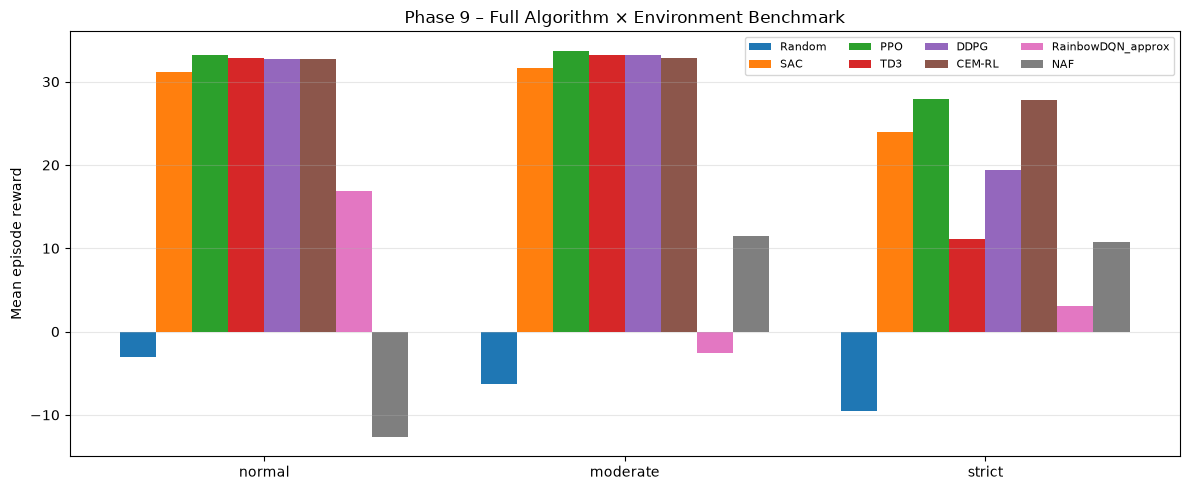


Cell 7 completed successfully.
PHASE 9 COMPLETED.


In [10]:
# Phase 9 – Cell 7: Final unified benchmark (all algorithms)

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import SAC, PPO, TD3, DDPG

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase9" / "models"
OUT_TAB = PROJECT / "outputs" / "phase9" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase9" / "figures"
OUT_DATA = PROJECT / "outputs" / "phase9" / "data"

print("=" * 60)
print("Phase 9 – Cell 7: Final benchmark")
print("=" * 60)

# Load continuous SB3 results by re-eval if zips exist
if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

base_features = np.load(P8 / "base_features.npy")
emb_tgn = np.load(P8 / "emb_TGN.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

def eval_sb3(cls, path, level, n_ep=10):
    model = cls.load(str(path))
    env = EconomicsNetworkEnv(base_features, emb_tgn, sr_vector, panel, nodes, level=level, seed=999)
    rewards, srs = [], []
    for ep in range(n_ep):
        obs, _ = env.reset(seed=999 + ep)
        done, tot, info = False, 0.0, {}
        while not done:
            a, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(a)
            tot += r
            done = term or trunc
        rewards.append(tot); srs.append(info.get("sr_improve", np.nan))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(srs)), float(np.nanstd(srs))

rows = []
levels = ["normal", "moderate", "strict"]
for level in levels:
    for name, cls in [("SAC", SAC), ("PPO", PPO), ("TD3", TD3), ("DDPG", DDPG)]:
        p = OUT_MODEL / f"{name}_{level}.zip"
        if p.exists():
            mr, sr, ms, ss = eval_sb3(cls, p, level)
            rows.append({"algorithm": name, "level": level, "mean_reward": mr, "std_reward": sr,
                         "mean_sr_improve": ms, "std_sr_improve": ss})
            print(f"{name:5s} | {level:8s} | R={mr:.3f} | dSR={ms:.3f}")

# append DQN/NAF/CEM table
extra = pd.read_csv(OUT_TAB / "comparison_dqn_naf_cem_3levels.csv")
rows.extend(extra.to_dict("records"))

# random baseline
rnd = pd.read_csv(PROJECT / "outputs" / "phase8" / "tables" / "random_baseline_3levels.csv")
for _, r in rnd.iterrows():
    rows.append({"algorithm": "Random", "level": r["level"], "mean_reward": r["mean_reward"],
                 "std_reward": r["std_reward"], "mean_sr_improve": r["mean_sr_improve"],
                 "std_sr_improve": r["std_sr_improve"]})

bench = pd.DataFrame(rows)
bench.to_csv(OUT_TAB / "phase9_full_benchmark_all.csv", index=False)
print("\n=== FULL BENCHMARK ===")
print(bench.sort_values(["level", "mean_reward"], ascending=[True, False]).to_string(index=False))

# Best env for main model SAC
sac = bench[bench["algorithm"] == "SAC"].sort_values("mean_reward", ascending=False)
best = sac.iloc[0]
print(f"\n>>> Best env for SAC (main): {best['level']} | R={best['mean_reward']:.4f} | dSR={best['mean_sr_improve']:.4f}")
pd.DataFrame([best]).to_csv(OUT_TAB / "best_sac_environment.csv", index=False)
(OUT_DATA / "best_sac_env.txt").write_text(str(best["level"]))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
algs = ["Random", "SAC", "PPO", "TD3", "DDPG", "CEM-RL", "RainbowDQN_approx", "NAF"]
x = np.arange(len(levels))
width = 0.1
for i, alg in enumerate(algs):
    vals = []
    for lv in levels:
        sub = bench[(bench.algorithm == alg) & (bench.level == lv)]
        vals.append(float(sub["mean_reward"].iloc[0]) if len(sub) else np.nan)
    ax.bar(x + i * width, vals, width, label=alg)
ax.set_xticks(x + 3.5 * width)
ax.set_xticklabels(levels)
ax.set_ylabel("Mean episode reward")
ax.set_title("Phase 9 – Full Algorithm × Environment Benchmark")
ax.legend(ncol=4, fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase9_full_benchmark_all.png", dpi=150)
plt.show()

print("\nCell 7 completed successfully.")
print("PHASE 9 COMPLETED.")

Phase 9 – Cell 5: Unified benchmark
SAC   | normal   | R=31.139±0.291 | dSR=1.160
PPO   | normal   | R=33.131±0.198 | dSR=1.160
TD3   | normal   | R=32.768±0.264 | dSR=1.160
DDPG  | normal   | R=32.713±0.213 | dSR=1.160
SAC   | moderate | R=31.510±0.659 | dSR=1.159
PPO   | moderate | R=33.607±0.477 | dSR=1.159
TD3   | moderate | R=33.048±0.391 | dSR=1.160
DDPG  | moderate | R=33.126±0.441 | dSR=1.160
SAC   | strict   | R=23.867±1.982 | dSR=1.109
PPO   | strict   | R=27.935±1.296 | dSR=1.107
TD3   | strict   | R=11.532±3.701 | dSR=0.859
DDPG  | strict   | R=19.841±3.770 | dSR=1.045

=== Full benchmark ===
algorithm    level  mean_reward  std_reward  mean_sr_improve  std_sr_improve
      PPO moderate    33.607391    0.476510         1.158930        0.009024
     DDPG moderate    33.126164    0.441483         1.159640        0.009016
      TD3 moderate    33.048314    0.390693         1.159640        0.009016
      SAC moderate    31.510070    0.659248         1.159468        0.009038
   

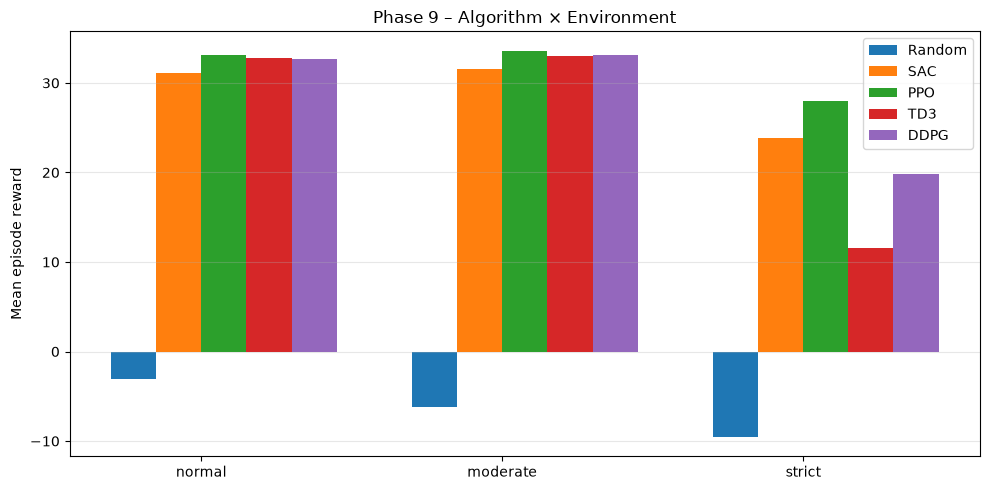


Note: Rainbow DQN / NAF / CEM-RL require discrete or custom adapters; continuous core completed.
Cell 5 completed successfully.
PHASE 9 CORE COMPLETED.


In [11]:
# Phase 9 – Stage I SRL | Cell 5: Full benchmark + best env for SAC

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import SAC, PPO, TD3, DDPG

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase9" / "models"
OUT_TAB = PROJECT / "outputs" / "phase9" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase9" / "figures"
OUT_DATA = PROJECT / "outputs" / "phase9" / "data"

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 9 – Cell 5: Unified benchmark")
print("=" * 60)

base_features = np.load(P8 / "base_features.npy")
emb_tgn = np.load(P8 / "emb_TGN.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

def evaluate_model(model, level, n_ep=15, seed=999):
    env = EconomicsNetworkEnv(base_features, emb_tgn, sr_vector, panel, nodes, level=level, seed=seed)
    rewards, srs = [], []
    for ep in range(n_ep):
        obs, _ = env.reset(seed=seed + ep)
        done, total_r, info = False, 0.0, {}
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            total_r += r
            done = term or trunc
        rewards.append(total_r)
        srs.append(info.get("sr_improve", np.nan))
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "mean_sr_improve": float(np.nanmean(srs)),
        "std_sr_improve": float(np.nanstd(srs)),
    }

# Load continuous algos trained
algo_map = {"SAC": SAC, "PPO": PPO, "TD3": TD3, "DDPG": DDPG}
levels = ["normal", "moderate", "strict"]
rows = []

for level in levels:
    # Random baseline from phase8 if exists
    for algo, cls in algo_map.items():
        path = OUT_MODEL / f"{algo}_{level}.zip"
        if not path.exists():
            print(f"Missing: {path.name}")
            continue
        model = cls.load(str(path))
        stats = evaluate_model(model, level)
        rows.append({"algorithm": algo, "level": level, **stats})
        print(f"{algo:5s} | {level:8s} | R={stats['mean_reward']:.3f}±{stats['std_reward']:.3f} | dSR={stats['mean_sr_improve']:.3f}")

# Random
rand_path = PROJECT / "outputs" / "phase8" / "tables" / "random_baseline_3levels.csv"
if rand_path.exists():
    rnd = pd.read_csv(rand_path)
    for _, r in rnd.iterrows():
        rows.append({
            "algorithm": "Random", "level": r["level"],
            "mean_reward": r["mean_reward"], "std_reward": r["std_reward"],
            "mean_sr_improve": r["mean_sr_improve"], "std_sr_improve": r["std_sr_improve"],
        })

bench = pd.DataFrame(rows)
bench.to_csv(OUT_TAB / "phase9_full_benchmark.csv", index=False)
print("\n=== Full benchmark ===")
print(bench.sort_values(["level", "mean_reward"], ascending=[True, False]).to_string(index=False))

# Best environment for main model SAC
sac = bench[bench["algorithm"] == "SAC"].copy()
if len(sac):
    best = sac.sort_values("mean_reward", ascending=False).iloc[0]
    print(f"\n>>> Best env for SAC: {best['level']} | reward={best['mean_reward']:.4f} | dSR={best['mean_sr_improve']:.4f}")
    pd.DataFrame([best]).to_csv(OUT_TAB / "best_sac_environment.csv", index=False)
    with open(OUT_DATA / "best_sac_env.txt", "w") as f:
        f.write(str(best["level"]))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
algs = ["Random", "SAC", "PPO", "TD3", "DDPG"]
x = np.arange(len(levels))
width = 0.15
for i, alg in enumerate(algs):
    vals = []
    for lv in levels:
        sub = bench[(bench.algorithm == alg) & (bench.level == lv)]
        vals.append(float(sub["mean_reward"].iloc[0]) if len(sub) else np.nan)
    ax.bar(x + i * width, vals, width, label=alg)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(levels)
ax.set_ylabel("Mean episode reward")
ax.set_title("Phase 9 – Algorithm × Environment")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase9_benchmark_bars.png", dpi=150)
plt.show()

print("\nNote: Rainbow DQN / NAF / CEM-RL require discrete or custom adapters; continuous core completed.")
print("Cell 5 completed successfully.")
print("PHASE 9 CORE COMPLETED.")